In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ushape.csv')

In [3]:
df.columns = ['X',"Y","class"]
df.head()

,X,Y,class
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


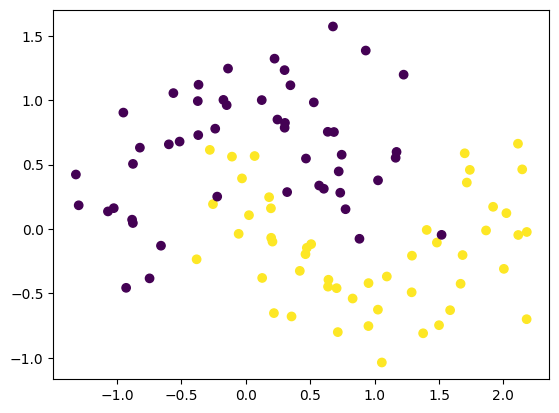

In [4]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [5]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [6]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

# For Relu

In [7]:
model = Sequential()

model.add(Dense(2,activation='relu',input_dim=2))
model.add(Dense(2,activation='relu'))
model.add(Dense(2,activation='relu'))
model.add(Dense(2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2)                 6         
                                                                 
 dense_1 (Dense)             (None, 2)                 6         
                                                                 
 dense_2 (Dense)             (None, 2)                 6         
                                                                 
 dense_3 (Dense)             (None, 2)                 6         
                                                                 
 dense_4 (Dense)             (None, 1)                 3         
                                                                 
Total params: 27
Trainable params: 27
Non-trainable params: 0
_________________________________________________________________


In [8]:
# Set parameters to 0
model.get_weights()

[array([[-0.3886274 ,  0.10524535],
        [-0.1664741 , -1.1297053 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.20055449, 1.1914283 ],
        [0.24983132, 0.24993873]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.41644502,  0.25383615],
        [-0.6921623 ,  1.1487876 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-1.017941 ,  0.8678757],
        [ 0.8390957,  0.6130744]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.13709664],
        [-0.5200203 ]], dtype=float32),
 array([0.], dtype=float32)]

In [9]:
model.get_weights()[1]

array([0., 0.], dtype=float32)

In [10]:
initial_weights = model.get_weights()

In [ ]:
# initial_weights[0] = np.random.rand(model.get_weights()[0].shape[0],model.get_weights()[0].shape[1])*1
# initial_weights[1] = np.zeros(model.get_weights()[1].shape)
# initial_weights[2] = np.random.rand(model.get_weights()[2].shape[0],model.get_weights()[2].shape[1])*1
# initial_weights[3] = np.zeros(model.get_weights()[3].shape)
# initial_weights[4] = np.random.rand(model.get_weights()[4].shape[0],model.get_weights()[4].shape[1])*1
# initial_weights[5] = np.zeros(model.get_weights()[5].shape)
# initial_weights[6] = np.random.rand(model.get_weights()[6].shape[0],model.get_weights()[6].shape[1])*1
# initial_weights[7] = np.zeros(model.get_weights()[7].shape)
# initial_weights[8] = np.random.rand(model.get_weights()[8].shape[0],model.get_weights()[8].shape[1])*1
# initial_weights[9] = np.zeros(model.get_weights()[9].shape)

for i in range(0, len(initial_weights), 2):
    # Weight matrix
    # *initial_weights[i].shape -> will give you dimension of the weight matrix (x,y)
    initial_weights[i] = np.random.rand(*initial_weights[i].shape) * 1

    # Bias vector
    initial_weights[i + 1] = np.zeros(initial_weights[i + 1].shape)

model.set_weights(initial_weights)

In [12]:
model.set_weights(initial_weights)

In [13]:
model.get_weights()

[array([[0.8884468 , 0.38588792],
        [0.14666183, 0.9809283 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.00830111, 0.5025221 ],
        [0.32981756, 0.39616635]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.35570133, 0.2715688 ],
        [0.05176686, 0.8644109 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.36803198, 0.9914904 ],
        [0.86369455, 0.85319155]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.6230239 ],
        [0.86666787]], dtype=float32),
 array([0.], dtype=float32)]

In [14]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 [==============================] - 2s 130ms/step - loss: 0.7904 - accuracy: 0.5570 - val_loss: 0.7137 - val_accuracy: 0.6500
Epoch 2/100
3/3 [==============================] - 0s 31ms/step - loss: 0.7841 - accuracy: 0.5570 - val_loss: 0.7101 - val_accuracy: 0.6500
Epoch 3/100
3/3 [==============================] - 0s 31ms/step - loss: 0.7761 - accuracy: 0.5570 - val_loss: 0.7068 - val_accuracy: 0.6500
Epoch 4/100
3/3 [==============================] - 0s 27ms/step - loss: 0.7702 - accuracy: 0.5443 - val_loss: 0.7036 - val_accuracy: 0.6500
Epoch 5/100
3/3 [==============================] - 0s 20ms/step - loss: 0.7627 - accuracy: 0.5316 - val_loss: 0.7006 - val_accuracy: 0.5500
Epoch 6/100
3/3 [==============================] - 0s 19ms/step - loss: 0.7573 - accuracy: 0.5316 - val_loss: 0.6976 - val_accuracy: 0.6000
Epoch 7/100
3/3 [==============================] - 0s 17ms/step - loss: 0.7507 - accuracy: 0.5443 - val_loss: 0.6946 - val_accuracy: 0.5500
Epoch 8/100
3/3 [==

In [15]:
model.get_weights()

[array([[ 1.0890062 ,  0.34158456],
        [-0.11077054,  0.83144635]], dtype=float32),
 array([-0.08305603, -0.14654428], dtype=float32),
 array([[-0.0896657 ,  0.6788788 ],
        [ 0.219157  ,  0.22278887]], dtype=float32),
 array([-0.11619072, -0.09825195], dtype=float32),
 array([[ 0.29230303,  0.15489304],
        [-0.01705308,  0.87385577]], dtype=float32),
 array([-0.07126018, -0.10151663], dtype=float32),
 array([[0.32236123, 0.9456203 ],
        [0.8685644 , 0.857758  ]], dtype=float32),
 array([-0.10352349, -0.1032986 ], dtype=float32),
 array([[0.6358239],
        [0.8734414]], dtype=float32),
 array([-0.12281775], dtype=float32)]

9600/9600 [==============================] - 14s 1ms/step


<Axes: >

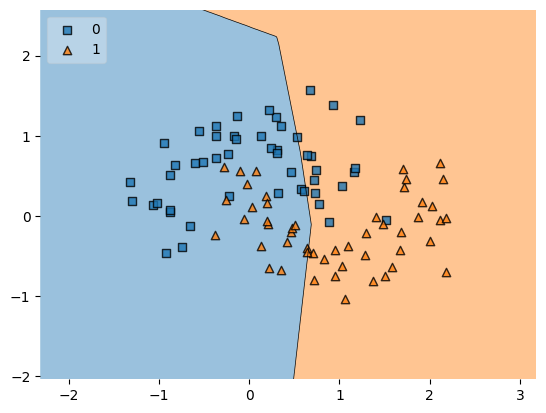

In [16]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

# tanh

In [17]:
model1 = Sequential()

model1.add(Dense(2,activation='tanh',input_dim=2))
model1.add(Dense(2,activation='tanh'))
model1.add(Dense(2,activation='tanh'))
model1.add(Dense(2,activation='tanh'))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 2)                 6         
                                                                 
 dense_6 (Dense)             (None, 2)                 6         
                                                                 
 dense_7 (Dense)             (None, 2)                 6         
                                                                 
 dense_8 (Dense)             (None, 2)                 6         
                                                                 
 dense_9 (Dense)             (None, 1)                 3         
                                                                 
Total params: 27
Trainable params: 27
Non-trainable params: 0
_________________________________________________________________


In [18]:
model1.get_weights()

[array([[-0.48832476,  0.17529404],
        [ 0.8067235 ,  1.1764258 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 1.2002734 ,  0.26038396],
        [-0.54235417,  0.5449083 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.8369688 ,  0.23243964],
        [ 0.9515821 , -1.1380867 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.60134673,  1.0528356 ],
        [ 1.1596977 , -0.38700712]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[1.3889688],
        [1.0085777]], dtype=float32),
 array([0.], dtype=float32)]

In [19]:
initial_weights1 = model1.get_weights()

In [20]:
# initial_weights1[0] = np.random.rand(model1.get_weights()[0].shape[0],model1.get_weights()[0].shape[1])*1
# initial_weights1[1] = np.zeros(model1.get_weights()[1].shape)
# initial_weights1[2] = np.random.rand(model1.get_weights()[2].shape[0],model1.get_weights()[2].shape[1])*1
# initial_weights1[3] = np.zeros(model1.get_weights()[3].shape)
# initial_weights1[4] = np.random.rand(model1.get_weights()[4].shape[0],model1.get_weights()[4].shape[1])*1
# initial_weights1[5] = np.zeros(model1.get_weights()[5].shape)
# initial_weights1[6] = np.random.rand(model1.get_weights()[6].shape[0],model1.get_weights()[6].shape[1])*1
# initial_weights1[7] = np.zeros(model1.get_weights()[7].shape)
# initial_weights1[8] = np.random.rand(model1.get_weights()[8].shape[0],model1.get_weights()[8].shape[1])*1
# initial_weights1[9] = np.zeros(model1.get_weights()[9].shape)

for i in range(0, len(initial_weights1), 2):
    # Weight matrix
    # *initial_weights1[i].shape -> will give you dimension of the weight matrix (x,y)
    initial_weights1[i] = np.random.rand(*initial_weights1[i].shape) * 1

    # Bias vector
    initial_weights1[i + 1] = np.zeros(initial_weights1[i + 1].shape)

model1.set_weights(initial_weights1)

In [21]:
model1.set_weights(initial_weights1)

In [22]:
model1.get_weights()

[array([[0.84985894, 0.20601794],
        [0.8085701 , 0.16584845]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.3777471 , 0.4786034 ],
        [0.32598823, 0.23530272]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.08375141, 0.24518852],
        [0.6591719 , 0.37500793]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.783173  , 0.11678834],
        [0.2752101 , 0.5846439 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.94332063],
        [0.9534249 ]], dtype=float32),
 array([0.], dtype=float32)]

In [23]:
model1.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

history = model1.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 [==============================] - 1s 80ms/step - loss: 0.7048 - accuracy: 0.5316 - val_loss: 0.6526 - val_accuracy: 0.7000
Epoch 2/100
3/3 [==============================] - 0s 24ms/step - loss: 0.7032 - accuracy: 0.5443 - val_loss: 0.6522 - val_accuracy: 0.7000
Epoch 3/100
3/3 [==============================] - 0s 24ms/step - loss: 0.7021 - accuracy: 0.5443 - val_loss: 0.6520 - val_accuracy: 0.7000
Epoch 4/100
3/3 [==============================] - 0s 24ms/step - loss: 0.7010 - accuracy: 0.5443 - val_loss: 0.6518 - val_accuracy: 0.7000
Epoch 5/100
3/3 [==============================] - 0s 22ms/step - loss: 0.6998 - accuracy: 0.5443 - val_loss: 0.6515 - val_accuracy: 0.7000
Epoch 6/100
3/3 [==============================] - 0s 23ms/step - loss: 0.6991 - accuracy: 0.5443 - val_loss: 0.6513 - val_accuracy: 0.7000
Epoch 7/100
3/3 [==============================] - 0s 24ms/step - loss: 0.6980 - accuracy: 0.5570 - val_loss: 0.6510 - val_accuracy: 0.7000
Epoch 8/100
3/3 [===

In [24]:
model1.get_weights()

[array([[ 1.0698787 ,  0.45148054],
        [ 0.5400566 , -0.19419894]], dtype=float32),
 array([ 0.11436711, -0.09710063], dtype=float32),
 array([[0.23936416, 0.3517524 ],
        [0.64010996, 0.5297062 ]], dtype=float32),
 array([-0.05652667, -0.0407327 ], dtype=float32),
 array([[0.18110351, 0.35165074],
        [0.6995396 , 0.4256047 ]], dtype=float32),
 array([-0.04369991, -0.04672911], dtype=float32),
 array([[0.8484613 , 0.19269286],
        [0.36319828, 0.68298185]], dtype=float32),
 array([-0.0456332, -0.0475734], dtype=float32),
 array([[1.0374465],
        [1.0774413]], dtype=float32),
 array([-0.04908995], dtype=float32)]

9600/9600 [==============================] - 14s 1ms/step


<Axes: >

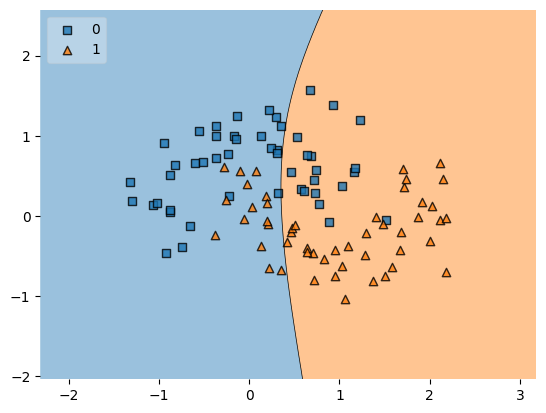

In [25]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model1, legend=2)

# Sigmoid

In [26]:
model2 = Sequential()

model2.add(Dense(2,activation='sigmoid',input_dim=2))
model2.add(Dense(2,activation='sigmoid'))
model2.add(Dense(2,activation='sigmoid'))
model2.add(Dense(2,activation='sigmoid'))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_10 (Dense)            (None, 2)                 6         
                                                                 
 dense_11 (Dense)            (None, 2)                 6         
                                                                 
 dense_12 (Dense)            (None, 2)                 6         
                                                                 
 dense_13 (Dense)            (None, 2)                 6         
                                                                 
 dense_14 (Dense)            (None, 1)                 3         
                                                                 
Total params: 27
Trainable params: 27
Non-trainable params: 0
_________________________________________________________________


In [27]:
model2.get_weights()

[array([[-1.0867307,  1.1647726],
        [ 0.9313179,  0.6687957]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.24181205, -0.19232237],
        [ 0.37973535,  0.0061717 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.03232169,  1.0806855 ],
        [-0.66230565,  0.46950233]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.05559719,  0.23126173],
        [ 0.35727692, -0.85201   ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.628374  ],
        [-0.68709373]], dtype=float32),
 array([0.], dtype=float32)]

In [28]:
initial_weights2 = model2.get_weights()

In [29]:
# initial_weights2[0] = np.random.rand(model2.get_weights()[0].shape[0],model2.get_weights()[0].shape[1])*1
# initial_weights2[1] = np.zeros(model2.get_weights()[1].shape)
# initial_weights2[2] = np.random.rand(model2.get_weights()[2].shape[0],model2.get_weights()[2].shape[1])*1
# initial_weights2[3] = np.zeros(model2.get_weights()[3].shape)
# initial_weights2[4] = np.random.rand(model2.get_weights()[4].shape[0],model2.get_weights()[4].shape[1])*1
# initial_weights2[5] = np.zeros(model2.get_weights()[5].shape)
# initial_weights2[6] = np.random.rand(model2.get_weights()[6].shape[0],model2.get_weights()[6].shape[1])*1
# initial_weights2[7] = np.zeros(model2.get_weights()[7].shape)
# initial_weights2[8] = np.random.rand(model2.get_weights()[8].shape[0],model2.get_weights()[8].shape[1])*1
# initial_weights2[9] = np.zeros(model2.get_weights()[9].shape)

for i in range(0, len(initial_weights2), 2):
    # Weight matrix
    # *initial_weights2[i].shape -> will give you dimension of the weight matrix (x,y)
    initial_weights2[i] = np.random.rand(*initial_weights2[i].shape) * 1

    # Bias vector
    initial_weights2[i + 1] = np.zeros(initial_weights2[i + 1].shape)

model2.set_weights(initial_weights2)

In [30]:
model2.set_weights(initial_weights2)

In [31]:
model2.get_weights()

[array([[0.65165395, 0.11938694],
        [0.32288435, 0.32621977]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.94798356, 0.3415101 ],
        [0.0852313 , 0.40097222]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.74958646, 0.7636096 ],
        [0.8858567 , 0.24422427]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.6949729 , 0.42054233],
        [0.62670046, 0.0464421 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.07194371],
        [0.90788895]], dtype=float32),
 array([0.], dtype=float32)]

In [32]:
model2.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

history = model2.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 [==============================] - 1s 74ms/step - loss: 0.7308 - accuracy: 0.5063 - val_loss: 0.7335 - val_accuracy: 0.5000
Epoch 2/100
3/3 [==============================] - 0s 17ms/step - loss: 0.7296 - accuracy: 0.5063 - val_loss: 0.7324 - val_accuracy: 0.5000
Epoch 3/100
3/3 [==============================] - 0s 22ms/step - loss: 0.7287 - accuracy: 0.5063 - val_loss: 0.7313 - val_accuracy: 0.5000
Epoch 4/100
3/3 [==============================] - 0s 22ms/step - loss: 0.7278 - accuracy: 0.5063 - val_loss: 0.7303 - val_accuracy: 0.5000
Epoch 5/100
3/3 [==============================] - 0s 20ms/step - loss: 0.7269 - accuracy: 0.5063 - val_loss: 0.7293 - val_accuracy: 0.5000
Epoch 6/100
3/3 [==============================] - 0s 22ms/step - loss: 0.7258 - accuracy: 0.5063 - val_loss: 0.7284 - val_accuracy: 0.5000
Epoch 7/100
3/3 [==============================] - 0s 23ms/step - loss: 0.7250 - accuracy: 0.5063 - val_loss: 0.7275 - val_accuracy: 0.5000
Epoch 8/100
3/3 [===

In [33]:
model2.get_weights()

[array([[0.8090353 , 0.2975725 ],
        [0.1595253 , 0.15192114]], dtype=float32),
 array([-0.1161494 , -0.10925497], dtype=float32),
 array([[ 0.8701901 ,  0.26129702],
        [-0.01765924,  0.2808968 ]], dtype=float32),
 array([-0.10607453, -0.12710333], dtype=float32),
 array([[0.62284386, 0.82940215],
        [0.7539894 , 0.31865352]], dtype=float32),
 array([-0.13920236,  0.08525261], dtype=float32),
 array([[ 0.7242661 ,  0.26912823],
        [ 0.66143996, -0.10953295]], dtype=float32),
 array([ 0.03552254, -0.157775  ], dtype=float32),
 array([[-0.09002975],
        [ 0.7512158 ]], dtype=float32),
 array([-0.16327219], dtype=float32)]

9600/9600 [==============================] - 14s 1ms/step


<Axes: >

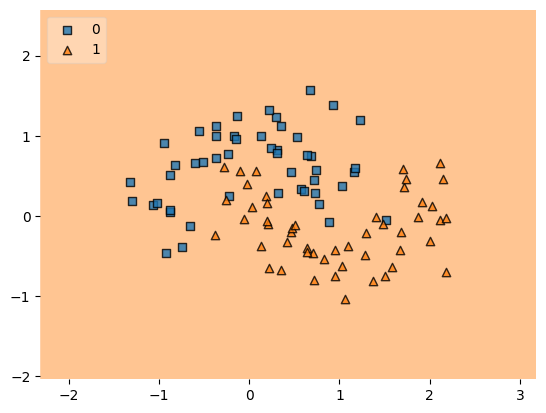

In [34]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model2, legend=2)